# 1. Importar todas las bibliotecas requeridas


In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [46]:
pwd

'/home/jf/Documentos/u/Santoto/2025-2/subjects/ai/04 chapters/05 GenAI'

# 2. Leer el dataset (csv)

Disponible en https://www.kaggle.com/datasets/iabhishekofficial/mobile-price-classification?resource=download


In [47]:
data = pd.read_csv("train.csv")

In [48]:
data.tail()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
1995,794,1,0.5,1,0,1,2,0.8,106,6,...,1222,1890,668,13,4,19,1,1,0,0
1996,1965,1,2.6,1,0,0,39,0.2,187,4,...,915,1965,2032,11,10,16,1,1,1,2
1997,1911,0,0.9,1,1,1,36,0.7,108,8,...,868,1632,3057,9,1,5,1,1,0,3
1998,1512,0,0.9,0,4,1,46,0.1,145,5,...,336,670,869,18,10,19,1,1,1,0
1999,510,1,2.0,1,5,1,45,0.9,168,6,...,483,754,3919,19,4,2,1,1,1,3


| Variable          | Significado                                                                                                                                           | Tipo / Unidad |
| ----------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------- | ------------- |
| **battery_power** | Capacidad de la batería del móvil medida en **mAh (miliamperios-hora)**.                                                                              | Numérica      |
| **blue**          | Indica si el teléfono **tiene Bluetooth**. <br>0 = No, 1 = Sí                                                                                         | Binaria       |
| **clock_speed**   | Velocidad del procesador medida en **GHz** (gigahercios).                                                                                             | Numérica      |
| **dual_sim**      | Indica si el teléfono **soporta doble SIM**. <br>0 = No, 1 = Sí                                                                                       | Binaria       |
| **fc**            | **Cámara frontal (front camera)** en **megapíxeles (MP)**.                                                                                            | Numérica      |
| **four_g**        | Indica si el móvil **soporta red 4G**. <br>0 = No, 1 = Sí                                                                                             | Binaria       |
| **int_memory**    | **Memoria interna** (almacenamiento) del teléfono en **GB**.                                                                                          | Numérica      |
| **m_dep**         | **Profundidad o grosor del móvil** en **centímetros**.                                                                                                | Numérica      |
| **mobile_wt**     | **Peso del móvil** en **gramos (g)**.                                                                                                                 | Numérica      |
| **n_cores**       | **Número de núcleos** del procesador.                                                                                                                 | Entera        |
| **pc**            | **Cámara principal (primary camera)** en **megapíxeles (MP)**.                                                                                        | Numérica      |
| **px_height**     | **Altura en píxeles** de la pantalla.                                                                                                                 | Numérica      |
| **px_width**      | **Anchura en píxeles** de la pantalla.                                                                                                                | Numérica      |
| **ram**           | **Memoria RAM** en **megabytes (MB)**.                                                                                                                | Numérica      |
| **sc_h**          | **Altura física** del móvil en **centímetros**.                                                                                                       | Numérica      |
| **sc_w**          | **Anchura física** del móvil en **centímetros**.                                                                                                      | Numérica      |
| **talk_time**     | **Tiempo máximo de conversación** posible con una carga completa, en **horas**.                                                                       | Numérica      |
| **three_g**       | Indica si el móvil **soporta red 3G**. <br>0 = No, 1 = Sí                                                                                             | Binaria       |
| **touch_screen**  | Indica si el teléfono **tiene pantalla táctil**. <br>0 = No, 1 = Sí                                                                                   | Binaria       |
| **wifi**          | Indica si el móvil **tiene conectividad Wi-Fi**. <br>0 = No, 1 = Sí                                                                                   | Binaria       |
| **price_range**   | **Etiqueta de clase (target)**: categoría del precio del móvil. <br>Generalmente toma valores de 0 a 3 (0 = bajo, 1 = medio, 2 = alto, 3 = muy alto). | Categórica    |


# 3. Análisis Exploratorio de los Datos (EDA)


In [49]:
data.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


In [50]:
data.corr()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
battery_power,1.000000,0.011252,0.011482,-0.041847,0.033334,0.015665,-0.004004,0.034085,0.001844,-0.029727,...,0.014901,-0.008402,-0.000653,-0.029959,-0.021421,0.052510,0.011522,-0.010516,-0.008343,0.200723
blue,0.011252,1.000000,0.021419,0.035198,0.003593,0.013443,0.041177,0.004049,-0.008605,0.036161,...,-0.006872,-0.041533,0.026351,-0.002952,0.000613,0.013934,-0.030236,0.010061,-0.021863,0.020573
clock_speed,0.011482,0.021419,1.000000,-0.001315,-0.000434,-0.043073,0.006545,-0.014364,0.012350,-0.005724,...,-0.014523,-0.009476,0.003443,-0.029078,-0.007378,-0.011432,-0.046433,0.019756,-0.024471,-0.006606
dual_sim,-0.041847,0.035198,-0.001315,1.000000,-0.029123,0.003187,-0.015679,-0.022142,-0.008979,-0.024658,...,-0.020875,0.014291,0.041072,-0.011949,-0.016666,-0.039404,-0.014008,-0.017117,0.022740,0.017444
fc,0.033334,0.003593,-0.000434,-0.029123,1.000000,-0.016560,-0.029133,-0.001791,0.023618,-0.013356,...,-0.009990,-0.005176,0.015099,-0.011014,-0.012373,-0.006829,0.001793,-0.014828,0.020085,0.021998
four_g,0.015665,0.013443,-0.043073,0.003187,-0.016560,1.000000,0.008690,-0.001823,-0.016537,-0.029706,...,-0.019236,0.007448,0.007313,0.027166,0.037005,-0.046628,0.584246,0.016758,-0.017620,0.014772
int_memory,-0.004004,0.041177,0.006545,-0.015679,-0.029133,0.008690,1.000000,0.006886,-0.034214,-0.028310,...,0.010441,-0.008335,0.032813,0.037771,0.011731,-0.002790,-0.009366,-0.026999,0.006993,0.044435
m_dep,0.034085,0.004049,-0.014364,-0.022142,-0.001791,-0.001823,0.006886,1.000000,0.021756,-0.003504,...,0.025263,0.023566,-0.009434,-0.025348,-0.018388,0.017003,-0.012065,-0.002638,-0.028353,0.000853
mobile_wt,0.001844,-0.008605,0.012350,-0.008979,0.023618,-0.016537,-0.034214,0.021756,1.000000,-0.018989,...,0.000939,0.000090,-0.002581,-0.033855,-0.020761,0.006209,0.001551,-0.014368,-0.000409,-0.030302
n_cores,-0.029727,0.036161,-0.005724,-0.024658,-0.013356,-0.029706,-0.028310,-0.003504,-0.018989,1.000000,...,-0.006872,0.024480,0.004868,-0.000315,0.025826,0.013148,-0.014733,0.023774,-0.009964,0.004399


In [51]:
data.corr()["price_range"]

battery_power    0.200723
blue             0.020573
clock_speed     -0.006606
dual_sim         0.017444
fc               0.021998
four_g           0.014772
int_memory       0.044435
m_dep            0.000853
mobile_wt       -0.030302
n_cores          0.004399
pc               0.033599
px_height        0.148858
px_width         0.165818
ram              0.917046
sc_h             0.022986
sc_w             0.038711
talk_time        0.021859
three_g          0.023611
touch_screen    -0.030411
wifi             0.018785
price_range      1.000000
Name: price_range, dtype: float64

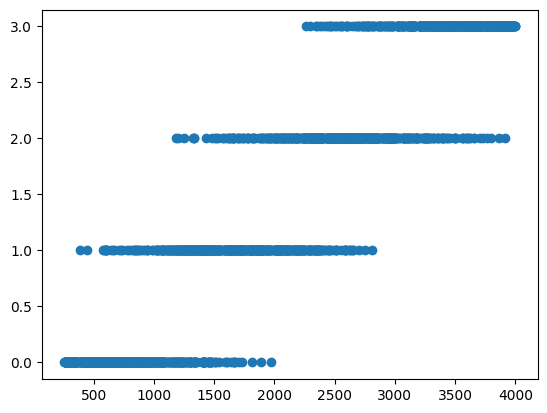

In [52]:
plt.scatter(data["ram"], data["price_range"])

# 4. Asignar las caracterśiticas (X) y el objetivo (Y)


In [53]:
data.columns

Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'price_range'],
      dtype='object')

In [54]:
X_columns = sorted(list(set(data.columns) - {"price_range"}))

In [55]:
X = data[X_columns].values
Y = data["price_range"].values

In [56]:
X, Y

(array([[8.420e+02, 0.000e+00, 2.200e+00, ..., 0.000e+00, 0.000e+00,
         1.000e+00],
        [1.021e+03, 1.000e+00, 5.000e-01, ..., 1.000e+00, 1.000e+00,
         0.000e+00],
        [5.630e+02, 1.000e+00, 5.000e-01, ..., 1.000e+00, 1.000e+00,
         0.000e+00],
        ...,
        [1.911e+03, 0.000e+00, 9.000e-01, ..., 1.000e+00, 1.000e+00,
         0.000e+00],
        [1.512e+03, 0.000e+00, 9.000e-01, ..., 1.000e+00, 1.000e+00,
         1.000e+00],
        [5.100e+02, 1.000e+00, 2.000e+00, ..., 1.000e+00, 1.000e+00,
         1.000e+00]], shape=(2000, 20)),
 array([1, 2, 2, ..., 3, 0, 3], shape=(2000,)))

# 5. Crear una FCN


In [57]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [58]:
num_features = len(data.columns) - 1  # Número de neuronas de entrada
num_classes = data["price_range"].nunique()  # Número de neuronas de salida

In [59]:
print(num_features, num_classes)

20 4


In [60]:
model = Sequential(
    [
        # Primer capa oculta con 60 neuronas
        Dense(60, activation="relu", input_shape=(num_features,)),
        # Segunda capa oculta con 40 neuronas
        Dense(40, activation="relu"),
        # Capa de salida con 4 neuronas de salida
        Dense(num_classes, activation="softmax"),
    ]
)

/home/jf/Documentos/u/Santoto/2025-2/subjects/ai/04 chapters/05 GenAI/.venv/lib64/python3.12/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [61]:
model.compile(
    optimizer="adam",  # Versión mejorada del gradiente descendente (SGD)
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [62]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 60)             │         1,260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 40)             │         2,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           164 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,864 (15.09 KB)

 Trainable params: 3,864 (15.09 KB)

 Non-trainable params: 0 (0.00 B)

- Input layer -> 20
- 1st hidden layer -> 60 => (20 \* 60) + 60 = 1260
- 2nd hidden layer -> 40 => (60 \* 40) + 40 = 2440
- Output layer -> 4 => (40 \* 4) + 4 = 164
- 1260 + 2440 + 164 = 3864


In [63]:
model.fit(X, Y, epochs=10, batch_size=50)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3900 - loss: 65.7377 
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4990 - loss: 11.4500
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5225 - loss: 7.2565
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5730 - loss: 4.6256
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5940 - loss: 3.8652
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5820 - loss: 3.7495
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6220 - loss: 3.1214
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5875 - loss: 3.6964
Epoch 9/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6065 - loss: 3.4521
Epoch 10/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6095 - loss: 3.4901


In [64]:
len(data) / 50  # len_data / batch_size = 40 samples per batch per epoch

40.0

In [65]:
model.save("model.keras")

# Pruebas del Modelo


In [66]:
test_data = pd.read_csv("test.csv")

In [67]:
test_data

,id,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,...,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,1,1043,1,1.8,1,14,0,5,0.1,193,...,16,226,1412,3476,12,7,2,0,1,0
1,2,841,1,0.5,1,4,1,61,0.8,191,...,12,746,857,3895,6,0,7,1,0,0
2,3,1807,1,2.8,0,1,0,27,0.9,186,...,4,1270,1366,2396,17,10,10,0,1,1
3,4,1546,0,0.5,1,18,1,25,0.5,96,...,20,295,1752,3893,10,0,7,1,1,0
4,5,1434,0,1.4,0,11,1,49,0.5,108,...,18,749,810,1773,15,8,7,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,1700,1,1.9,0,0,1,54,0.5,170,...,17,644,913,2121,14,8,15,1,1,0
996,997,609,0,1.8,1,0,0,13,0.9,186,...,2,1152,1632,1933,8,1,19,0,1,1
997,998,1185,0,1.4,0,1,1,8,0.5,80,...,12,477,825,1223,5,0,14,1,0,0
998,999,1533,1,0.5,1,0,0,50,0.4,171,...,12,38,832,2509,15,11,6,0,1,0


In [68]:
X_test = test_data[X_columns].values

In [69]:
len(X_test)

1000

In [72]:
Y_pred = model.predict(X_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [ ]:
Y_pred

array([[3.7770381e-13, 5.8720286e-08, 2.5034036e-05, 9.9997491e-01],
       [6.2980117e-35, 1.4557297e-15, 1.9151895e-11, 9.9999994e-01],
       [7.9110438e-01, 5.8434545e-03, 1.2599853e-04, 2.0292610e-01],
       ...,
       [4.3293098e-06, 6.7918847e-04, 9.9929929e-01, 1.7120923e-05],
       [1.6012718e-04, 1.0307907e-01, 8.9676005e-01, 7.9457993e-07],
       [2.0924431e-09, 1.3182541e-04, 1.0275875e-01, 8.9710939e-01]],
      shape=(1000, 4), dtype=float32)

In [74]:
Y_pred = np.argmax(Y_pred, axis=-1)

In [75]:
Y_pred

array([3, 3, 0, 3, 2, 3, 3, 1, 3, 0, 3, 3, 0, 0, 2, 0, 2, 1, 3, 2, 0, 3,
       2, 3, 3, 0, 2, 0, 3, 1, 2, 0, 3, 0, 0, 1, 3, 2, 3, 3, 1, 1, 1, 0,
       0, 1, 1, 3, 1, 2, 3, 0, 3, 1, 3, 0, 3, 1, 1, 3, 3, 2, 1, 2, 1, 1,
       1, 3, 0, 1, 1, 2, 1, 3, 3, 0, 3, 0, 3, 3, 1, 3, 3, 0, 3, 0, 3, 1,
       2, 1, 2, 2, 2, 0, 3, 3, 0, 1, 0, 3, 3, 0, 0, 3, 1, 1, 0, 1, 3, 3,
       3, 3, 1, 3, 3, 3, 3, 1, 3, 0, 0, 3, 3, 1, 2, 0, 3, 3, 3, 1, 0, 1,
       1, 1, 3, 1, 1, 0, 3, 3, 3, 3, 1, 1, 2, 3, 3, 2, 1, 3, 3, 3, 1, 0,
       2, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 3, 1, 0, 3, 0, 0, 0, 1, 1, 0, 2,
       1, 0, 1, 2, 1, 0, 1, 1, 3, 2, 0, 1, 0, 0, 0, 1, 0, 3, 1, 0, 2, 3,
       3, 3, 1, 3, 3, 3, 3, 1, 1, 1, 1, 1, 3, 3, 2, 2, 3, 3, 1, 3, 0, 3,
       3, 2, 3, 1, 0, 1, 0, 3, 0, 2, 0, 3, 0, 0, 3, 0, 3, 0, 3, 1, 2, 0,
       0, 3, 1, 2, 3, 3, 1, 1, 3, 0, 0, 3, 3, 3, 1, 3, 2, 1, 3, 3, 1, 3,
       3, 3, 3, 2, 0, 1, 2, 3, 2, 3, 3, 1, 0, 3, 0, 2, 2, 1, 0, 3, 2, 3,
       3, 2, 0, 3, 2, 2, 3, 1, 2, 1, 1, 0, 3, 3, 1,

In [76]:
test_data["price_range_predicted"] = Y_pred

In [77]:
test_data

,id,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range_predicted
0,1,1043,1,1.8,1,14,0,5,0.1,193,...,226,1412,3476,12,7,2,0,1,0,3
1,2,841,1,0.5,1,4,1,61,0.8,191,...,746,857,3895,6,0,7,1,0,0,3
2,3,1807,1,2.8,0,1,0,27,0.9,186,...,1270,1366,2396,17,10,10,0,1,1,0
3,4,1546,0,0.5,1,18,1,25,0.5,96,...,295,1752,3893,10,0,7,1,1,0,3
4,5,1434,0,1.4,0,11,1,49,0.5,108,...,749,810,1773,15,8,7,1,0,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,1700,1,1.9,0,0,1,54,0.5,170,...,644,913,2121,14,8,15,1,1,0,2
996,997,609,0,1.8,1,0,0,13,0.9,186,...,1152,1632,1933,8,1,19,0,1,1,1
997,998,1185,0,1.4,0,1,1,8,0.5,80,...,477,825,1223,5,0,14,1,0,0,2
998,999,1533,1,0.5,1,0,0,50,0.4,171,...,38,832,2509,15,11,6,0,1,0,2
